# Assignment 5 — Phần 1: Khái Niệm Cơ Bản Về CNN & Các Hàm Code Tương Ứng

**Môn học:** Phát triển Hệ thống Thông minh (Smart System)  
**Nội dung:** Tìm hiểu bản chất toán học, nguyên lý hoạt động của Mạng nơ-ron tích chập (Convolutional Neural Networks - CNN) và đối chiếu chi tiết các hàm code trong hai framework hàng đầu: **TensorFlow/Keras** và **PyTorch**.

## 1. Tổng quan: Tại sao cần CNN thay vì MLP (Mạng nơ-ron truyền thẳng)?

- **Sự bùng nổ tham số (Parameter Explosion):** Khi đưa ảnh đầu vào kích thước $224 \times 224 \times 3$ vào MLP, một lớp ẩn 1000 nơ-ron cần tới $(224 \times 224 \times 3) \times 1000 \approx 150$ triệu trọng số, dẫn đến overfitting nghiêm trọng và quá tải bộ nhớ.
- **Mất thông tin không gian (Loss of Spatial Locality):** MLP trải phẳng ảnh thành vector 1D, làm mất toàn bộ mối tương quan lân cận giữa các pixel lân cận (hàng xóm không gian).
- **Giải pháp của CNN:** Sử dụng 2 nguyên lý then chốt:
  1. **Trường tiếp nhận cục bộ (Local Receptive Fields):** Mỗi nơ-ron chỉ kết nối với một vùng lân cận nhỏ của đầu vào.
  2. **Chia sẻ trọng số (Weight Sharing):** Cùng một bộ lọc (Kernel) được trượt trên toàn bộ ảnh, phát hiện đặc trưng ở mọi vị trí (Translation Invariance).

## 2. Các Khái Niệm Cốt Lõi Của CNN

### A. Phép Tích Chập (Convolutional Operation)
Phép tích chập 2D rời rạc giữa ảnh $I$ và Kernel $K$ kích thước $k_h \times k_w$ được tính theo công thức:
$$S(i, j) = (I * K)(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m, j+n) K(m, n) + b$$

### B. Stride & Padding
- **Stride ($S$):** Bước nhảy của Kernel khi trượt qua ảnh. Stride > 1 giúp giảm kích thước feature map.
- **Padding ($P$):** Đệm các giá trị 0 xung quanh viền ảnh.
  - `Valid` (No padding): $P = 0$, ảnh đầu ra bị co lại.
  - `Same` (Half padding): Đệm sao cho khi $S=1$, kích thước không gian đầu ra bằng đầu vào.
- **Công thức tính kích thước đầu ra:**
$$O = \left\lfloor \frac{I - K + 2P}{S} \right\rfloor + 1$$

### C. Pooling (Gộp mẫu)
- **Max Pooling:** Chọn giá trị lớn nhất trong cửa sổ gộp (ví dụ $2\times 2$), giữ lại đặc trưng kích hoạt mạnh nhất.
- **Average Pooling:** Lấy trung bình cộng các giá trị trong cửa sổ.

### D. Flatten & Fully Connected Layer
- **Flatten:** Duỗi tensor đặc trưng đa chiều thành vector 1D.
- **Dense / Linear Layer:** Kết nối toàn bộ đặc trưng trích xuất được tới các nút phân loại đầu ra.

### E. Regularization: Batch Normalization & Dropout
- **Batch Normalization (BN):** Chuẩn hóa tensor kích hoạt theo từng mini-batch, ổn định phân phối trung gian, tăng tốc độ hội tụ.
- **Dropout:** Ngẫu nhiên ngắt kết nối (set về 0) một tỷ lệ nơ-ron trong quá trình train để chống phụ thuộc đồng phát (co-adaptation).

## 3. Bảng Đối Chiếu Các Hàm Code: Keras vs PyTorch

| Thành phần | Keras / TensorFlow API | PyTorch Module API |
| :--- | :--- | :--- |
| **Tích chập 2D** | `tf.keras.layers.Conv2D(filters, kernel_size, strides, padding, activation)` | `torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)` |
| **Tích chập 1D (Bảng)**| `tf.keras.layers.Conv1D(filters, kernel_size, strides, padding)` | `torch.nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)` |
| **Max Pooling 2D** | `tf.keras.layers.MaxPooling2D(pool_size, strides)` | `torch.nn.MaxPool2d(kernel_size, stride)` |
| **Max Pooling 1D** | `tf.keras.layers.MaxPooling1D(pool_size, strides)` | `torch.nn.MaxPool1d(kernel_size, stride)` |
| **Batch Normalization** | `tf.keras.layers.BatchNormalization()` | `torch.nn.BatchNorm2d(num_features)` / `BatchNorm1d` |
| **Dropout** | `tf.keras.layers.Dropout(rate)` | `torch.nn.Dropout(p)` / `torch.nn.Dropout2d(p)` |
| **Flatten** | `tf.keras.layers.Flatten()` | `torch.nn.Flatten()` hoặc `torch.flatten(x, 1)` |
| **Fully Connected** | `tf.keras.layers.Dense(units, activation)` | `torch.nn.Linear(in_features, out_features)` |
| **Hàm kích hoạt** | `tf.keras.layers.ReLU()`, `Softmax()` | `torch.nn.ReLU()`, `torch.nn.Softmax(dim=1)` |
| **Hàm mất mát** | `tf.keras.losses.SparseCategoricalCrossentropy()` | `torch.nn.CrossEntropyLoss()` |
| **Thuật toán tối ưu** | `tf.keras.optimizers.Adam(learning_rate)` | `torch.optim.Adam(model.parameters(), lr)` |

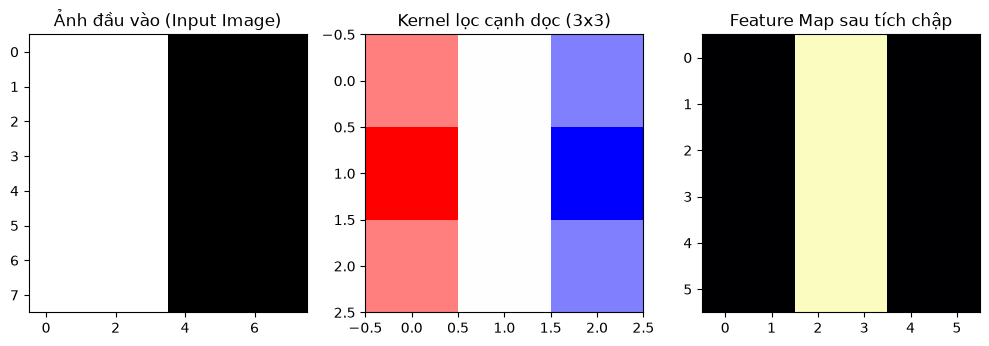

In [1]:
# Minh họa trực quan phép tích chập (Convolution) bằng NumPy và Matplotlib
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo ma trận ảnh giả lập (8x8) có cạnh dọc rõ nét
img = np.zeros((8, 8))
img[:, :4] = 10
img[:, 4:] = 0

# 2. Bộ lọc Sobel phát hiện cạnh dọc (Vertical Edge Detection Filter)
kernel = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1]
])

# 3. Tính toán tích chập thủ công
out_h = img.shape[0] - kernel.shape[0] + 1
out_w = img.shape[1] - kernel.shape[1] + 1
feature_map = np.zeros((out_h, out_w))

for i in range(out_h):
    for j in range(out_w):
        receptive_field = img[i:i+3, j:j+3]
        feature_map[i, j] = np.sum(receptive_field * kernel)

# 4. Vẽ kết quả minh họa trích xuất cạnh
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Ảnh đầu vào (Input Image)")
axes[1].imshow(kernel, cmap='bwr')
axes[1].set_title("Kernel lọc cạnh dọc (3x3)")
axes[2].imshow(feature_map, cmap='magma')
axes[2].set_title("Feature Map sau tích chập")
plt.tight_layout()
plt.show()

In [2]:
# Đối chiếu code xây dựng mạng CNN: Keras vs PyTorch
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn

# A. Triển khai bằng Keras Sequential API
keras_cnn = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation='softmax')
])
print("=== KERAS CNN SUMMARY ===")
keras_cnn.summary()

# B. Triển khai bằng PyTorch nn.Module
class PyTorchCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 7 * 7, 10)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        return self.fc(x)

pt_cnn = PyTorchCNN()
print("\n=== PYTORCH CNN ARCHITECTURE ===")
print(pt_cnn)

=== KERAS CNN SUMMARY ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,186 (196.04 KB)

 Trainable params: 50,186 (196.04 KB)

 Non-trainable params: 0 (0.00 B)


=== PYTORCH CNN ARCHITECTURE ===
PyTorchCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=3136, out_features=10, bias=True)
  (relu): ReLU()
)
